In [1]:
%matplotlib inline

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)

import matplotlib.pyplot as plt
from IPython.display import display

import torch
import numpy as np

from deeplens.geolens import GeoLens
from deeplens.geometric_surface import Aspheric, Aperture, Plane
from deeplens.diffractive_surface import DoeGSL

from src.vis import img_crop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# optics configuration
wvln_um = 0.7
gap_doe_lens = 3.0
d_sensor = 50 + gap_doe_lens

# ==============================
# Surface 0: Aperture, same as surface 1
# ==============================
aperture = Aperture(
    r=12.7,  
    d=0.0,
    device=device,
)

# ==============================
# Surface 1: Grating implement by generlaized Snell's law
# ==============================
def linear_phase(x, y, wvln):
    """ Phase function: phi = const * x """
    const = 30.0
    return const * x

grating = DoeGSL(
    r=12.7,  
    d=0.0, 
    mat2='air',  
    phase_func=linear_phase,
    device=device,
)

# ==============================
# Surface 2, 3: LA1131: N-BK7 material
# ==============================
lens_front = Aspheric(
    r=12.7,  
    d=0.0 + gap_doe_lens, 
    c=1/25.8,  
    k=0.0, 
    ai=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0],  
    mat2='1.5131/inf',  # N-BK7
    device=device,
)

lens_back = Aspheric(
    r=12.7,
    d=5.3 + gap_doe_lens,  # z position in mm (LA1131: center thickness = 5.3 mm)
    c=0.0,
    k=0.0,
    ai=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 
    mat2='air',
    device=device,
)

In [3]:
# Deeplens setup
lens = GeoLens(primary_wvln=wvln_um, device=device)
lens.float_enpd = True
lens.float_foclen = False
lens.float_hfov = False
lens.enpd = None

lens.surfaces = [aperture, grating, lens_front, lens_back]

# sensor
sensor_pixel_pitch = wvln_um / 1000 / 2
sensor_resolution = 1001
sensor_size = sensor_resolution * sensor_pixel_pitch
lens.d_sensor = torch.tensor(d_sensor) 
lens.set_sensor(sensor_res=(sensor_resolution, sensor_resolution), sensor_size=(sensor_size, sensor_size))

lens.post_computation()

No intersection points found, use the last surface as exit pupil.


In [4]:
# normal incident PSF
incident_ray_count = 2**18
ray = lens.sample_from_points(
    points=torch.tensor([[0, 0, -100000.0]], dtype=torch.float64),
    num_rays=incident_ray_count, 
    wvln=wvln_um,)
ray.is_coherent = True

Xg, Yg, _, psf = lens.huygens_psf(ray, oversamp=2.0)

PSF center (um): x = 160.65, y = 0.35


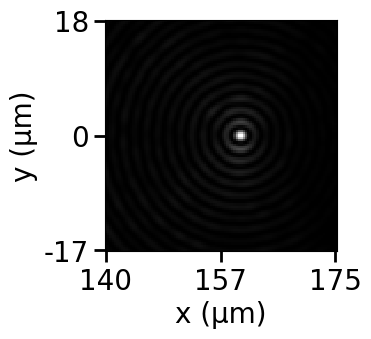

In [5]:
# crop psf and plot
Xg_crop, Yg_crop, psf_crop = img_crop(Xg, Yg, psf, crop_size=101)

fig, ax = plt.subplots(figsize=(3.5, 3.5), facecolor="none")
ax.set_aspect("equal")
ax.pcolormesh(
    Xg_crop.detach().cpu().numpy(),
    Yg_crop.detach().cpu().numpy(),
    psf_crop.detach().cpu().numpy(),
    cmap="gray",
)

xticks_um = np.linspace(Xg_crop.min().detach().cpu().item(), Xg_crop.max().detach().cpu().item(), 3) * 1000
yticks_um = np.linspace(Yg_crop.min().detach().cpu().item(), Yg_crop.max().detach().cpu().item(), 3) * 1000

ax.set_xticks(xticks_um / 1000)
ax.set_yticks(yticks_um / 1000)
ax.set_xticklabels([f"{v:.0f}" for v in xticks_um], fontsize=20)
ax.set_yticklabels([f"{v:.0f}" for v in yticks_um], fontsize=20)
ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=20)

ax.set_xlabel("x (μm)", fontsize=20)
ax.set_ylabel("y (μm)", fontsize=20)

plt.tight_layout(pad=0)